# なぜ「単独では負ける対策」が、組み合わせると勝つのか？
## Perth の雑草モデルで見る Parrondo 型の逆転 — 10分デモ

**問い：高密度を処理する A と、中密度の拡散源を処理する B は、順序によって結果が変わるか？**

ここで「勝つ」は **最後の平均 Weed Index が初期値より低い**ことです。実際の雑草量・金額を予測するモデルではありません。
結論を先に言うと、選んだ条件では100ステップ後に逆転が起きます。ただし長期には維持されず、ランダムな順序でも成功します。

読み順：①問い・モデル（2分）→ ②逆転と公平な比較（3分）→ ③なぜ起きるか（2分）→ ④限界・結論（2分）。残り1分を実演に使います。
日本語の説明と、文字化けを避けた英語の図ラベルで構成しています。**Kernel restart → Run All** で代表条件を再計算できます。
大きな探索・400通りのランダム検証は再実行せず、既存CSVを読みます。

### 1. Step01〜10 は何を確かめたか

|実験|問い|デモでの役割|
|---|---|---|
|Step01|何もしないとどうなる？|無処理の基準|
|Step02–03|A、Bそれぞれで抑制できる？|単独対策の比較|
|Step04|交互実行は単独より良い？|逆転の候補|
|Step05–06|どの条件で初期値を下回る？|探索と再検証|
|Step07|順番や予算の違いでは？|ブロック・ランダム・予算上限による対照|
|Step08|共通予算上限でも逆転する？|代表候補2036|
|Step09|どのパラメータと関連する？|2,400条件の探索。因果的な感度分析ではない|
|Step10|期間や環境を変えても成立する？|成功する範囲と失敗する条件|

以下は各ステップの過去の図をそのまま並べるのではなく、**Step08の代表条件に統一した再実験**です。
元の Step01–07 とは設定が異なるため、数値をそのまま比較しません。

In [1]:
from pathlib import Path
import os, sys
ROOT = next(p for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
            if (p / "src" / "weed_ca.py").exists())
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from src.data_loader import load_locality_data
from src.weed_experiment import ExperimentConfig, run_experiment
from src.experiment_schedules import PolicyParameters, make_scheduled_policy, standard_schedules
plt.rcParams.update({"figure.dpi": 110, "font.size": 11})
print("Python:", sys.version.split()[0])
print("Project:", ROOT)

Python: 3.14.4
Project: C:\Users\kazut\Documents\ChatGPT\cits4403_computational_model


### 2. モデル：増える → 周囲から広がる → 対策で減る

1セルは **1 km × 1 km**、状態 $W_i\in[0,1]$ は相対的な雑草指数です。郵便番号6000–6199のポリゴンを使い、域外セルは除外します。
初期値は人口密度 $P_i$ から $W_i(0)=0.05+0.95\exp(-0.000783P_i)$ と設定します。
「人口が多いと管理が強い」という仮定であり、観測された雑草分布ではありません。

$$G_i=rW_i(1-W_i),\qquad
D_i=\alpha\sum_{j\in N_8(i)}\max(W_j^{\mathrm{growth}}-W_i^{\mathrm{growth}},0).$$

成長、8近傍からの伝播、除去の順に更新し、各段階で上限1に切り詰めます。
伝播は低いセルを増やしますが、高いセルを減らしません。**質量保存型の拡散ではありません。**
境界は反対側へつながりません。時間は校正していない「モデルのステップ」として扱います。

|対策|対象|優先順位|代表条件での除去|
|---|---|---|---|
|A|$W\geq0.7$|雑草指数が高い順|15%ずつ、最大50セル/回|
|B|$0.45\leq W<0.7$、かつ外向き伝播スコアが正|$\sum_j\max(W_i-W_j,0)$ が大きい順|65%ずつ、最大50セル/回|

Bは単に「中密度をすべて処理」するわけではありません。隣より高く、広げる可能性のあるセルを優先します。
費用は除去した指数の総量×200というモデル内単位です。全戦略の予算**上限**は250,000。実際の支出は同額とは限りません。

In [2]:
finalists = pd.read_csv(ROOT / "results/strong_parrondo_finalists.csv")
candidate = finalists.set_index("sample_id").loc[2036]
params = PolicyParameters(a_rate=float(candidate.a_rate), b_rate=float(candidate.b_rate),
    max_cells=int(candidate.max_cells), boundary=float(candidate.boundary),
    b_lower=float(candidate.b_lower))
config = ExperimentConfig(growth_rate=float(candidate.growth_rate),
                          diffusion_rate=float(candidate.diffusion_rate), steps=100)
budget = float(candidate.budget)
localities = load_locality_data()
metro = localities[localities.postcode.astype(int).between(6000, 6199)].copy()
display(pd.Series({"sample_id": 2036, "growth r": config.growth_rate,
    "spread alpha": config.diffusion_rate, "steps": config.steps,
    "cell size (m)": config.cell_size, "budget cap": budget,
    "A removal": params.a_rate, "B removal": params.b_rate,
    "max cells per call": params.max_cells, "A/B boundary": params.boundary,
    "B lower bound": params.b_lower}, name="Representative condition").to_frame())

C:\Users\kazut\Documents\ChatGPT\cits4403_computational_model\src\data_loader.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  census["postcode"] = (


,Representative condition
sample_id,2036.00
growth r,0.01
spread alpha,0.01
steps,100.00
cell size (m),1000.00
budget cap,250000.00
A removal,0.15
B removal,0.65
max cells per call,50.00
A/B boundary,0.70


### 3. 同じ初期状態から比較する

無処理、Aのみ、Bのみ、ABAB…、BABA…、Aを50回→Bを50回、その逆を実行します。
混合戦略のAとBの呼出し回数はすべて50回ずつです。実際に処理するセル数・除去量は、その時点の状態によって変わります。

In [3]:
schedules = standard_schedules(config.steps)
runs = {"No control": run_experiment("No control", metro, config)}
for name, schedule in schedules.items():
    runs[name] = run_experiment(name, metro, config,
        make_scheduled_policy(schedule, params, budget))
summary = pd.DataFrame([{"strategy": name, "initial": x.initial_mean,
    "final": x.final_mean, "change (%)": 100*x.relative_change,
    "actual cost": x.final_cost,
    "cumulative index": float(np.trapezoid(x.mean_weed))}
    for name, x in runs.items()]).set_index("strategy")
display(summary.round(4))
# Mathematical invariants and the six inequalities behind this example.
for result in runs.values():
    assert np.allclose(result.history[0], runs["No control"].history[0], equal_nan=True)
    valid = np.isfinite(result.history)
    assert np.all((result.history[valid] >= 0) & (result.history[valid] <= 1))
    assert result.final_cost <= budget + 0.1
assert (summary.loc[["A only", "B only", "A block B", "B block A"], "change (%)"] > 0).all()
assert (summary.loc[["AB", "BA"], "change (%)"] < 0).all()
print("Same initial grids, valid states, budget caps and endpoint reversal: verified")

Same initial grids, valid states, budget caps and endpoint reversal: verified


,initial,final,change (%),actual cost,cumulative index
strategy,,,,,
No control,0.8606,0.9582,11.3418,0.0000,91.7009
A only,0.8606,0.8967,4.1958,149107.4844,87.9491
B only,0.8606,0.8728,1.4206,199967.1719,86.3967
AB,0.8606,0.8588,-0.2064,228212.6562,85.8039
BA,0.8606,0.8576,-0.3486,229166.3594,85.6724
A block B,0.8606,0.9011,4.7051,138087.8750,87.6856
B block A,0.8606,0.8863,2.9926,173466.4219,86.7525


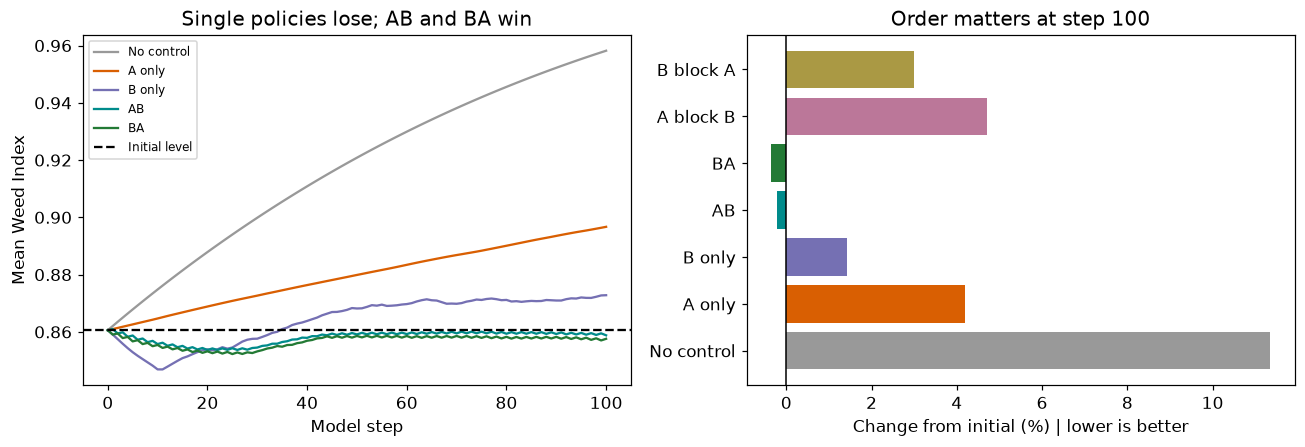

In [4]:
colors = {"No control": "#999999", "A only": "#d95f02", "B only": "#7570b3",
          "AB": "#008b8b", "BA": "#237a35", "A block B": "#bb7799", "B block A": "#aa9944"}
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for name in ["No control", "A only", "B only", "AB", "BA"]:
    axes[0].plot(runs[name].mean_weed, label=name, color=colors[name])
axes[0].axhline(runs["AB"].initial_mean, color="black", ls="--", label="Initial level")
axes[0].set(xlabel="Model step", ylabel="Mean Weed Index", title="Single policies lose; AB and BA win")
axes[0].legend(fontsize=8)
axes[1].barh(summary.index, summary["change (%)"], color=[colors[n] for n in summary.index])
axes[1].axvline(0, color="black", lw=1)
axes[1].set(xlabel="Change from initial (%) | lower is better", title="Order matters at step 100")
fig.tight_layout(); plt.show()

**図の読み方：** 右図の0より左が改善、右が悪化です。
$\Delta=(\bar W_{100}-\bar W_0)/\bar W_0$ と定義すると、$\Delta_A>0,\Delta_B>0$ なのに $\Delta_{AB}<0,\Delta_{BA}<0$ となります。
これは有限期間の **Parrondo 型の逆転**です。「負け」は無処理より悪いという意味ではありません。
単独対策でも無処理よりは改善していて、初期値を下回れないだけです。

ブロック実行は同じ回数のAとBでも失敗します。一方、予算上限が共通でもAB/BAはより多く支出しています。
したがって「同じ支出で優れる」とは結論できません。処理対象の増加による支出の違いも効果の一部です。

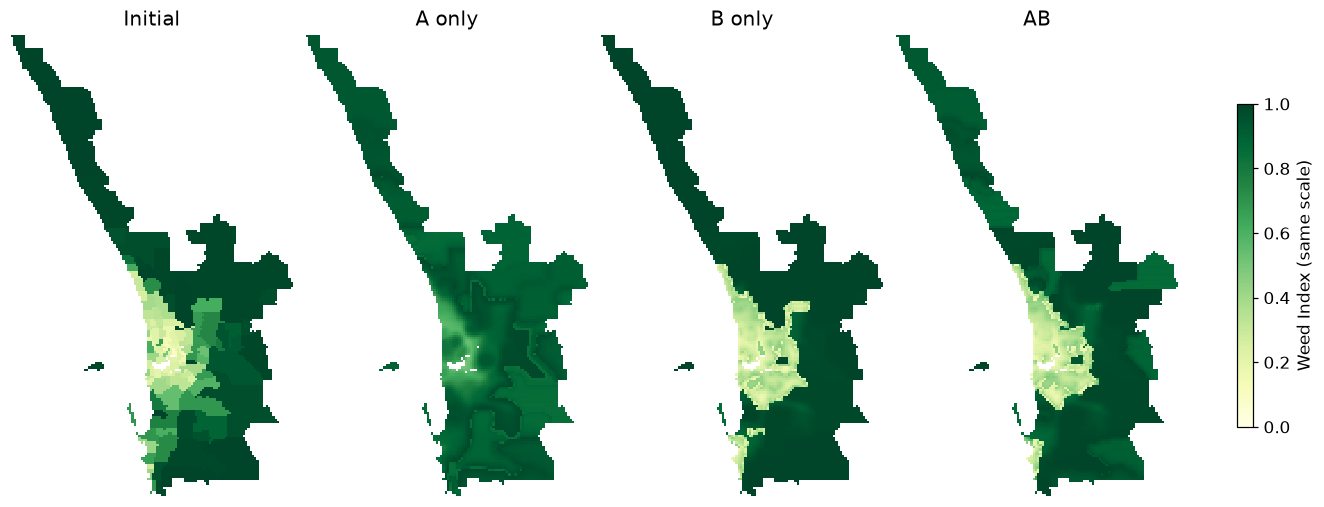

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(12, 4.5), constrained_layout=True)
for ax, name in zip(axes, ["Initial", "A only", "B only", "AB"]):
    grid = runs["AB"].history[0] if name == "Initial" else runs[name].history[-1]
    im = ax.imshow(grid, vmin=0, vmax=1, cmap="YlGn", interpolation="nearest")
    ax.set_title(name); ax.set_axis_off()
fig.colorbar(im, ax=axes, shrink=.7, label="Weed Index (same scale)")
plt.show()

### 4. なぜ起きる？ まず「AからBへの引き継ぎ説」を検証する

例えば雑草指数が0.80のセルはBには高すぎます。Aが15%除去すると0.68になり、Bの範囲に入ります。
次のステップでも範囲内で、周りへの伝播スコアと順位の条件を満たせば、Bがさらに65%除去できます。
成長・伝播を無視した説明用の計算では 0.80 → 0.68 → 0.238 です。

**Aだけでは中密度になったセルを処理できず、Bだけでは高密度のセルに手を付けられません。**
ただし、Aは指数の高いセルから選ぶため、0.80の例が実際に起きるとは限りません。
上の計算は仮説の説明であって、観測結果ではありません。
次のセルは、本当にこの引き継ぎが起きたかを、既存の政策を変更せず記録します。

測定するのは「Aの直後にBの密度範囲へ入ったセル」と「その中で次ステップのBが実際に処理したセル」です。
後者には成長、伝播、順位、予算の条件も反映されます。同じセルが複数回登場するため、集計は**延べ処理回数**です。

**実測：A後にBの密度範囲へ入った延べ 0 セルのうち、次のBで処理されたのは 0 セル。** これはBの全処理 2,392 セルの 0.0% です。

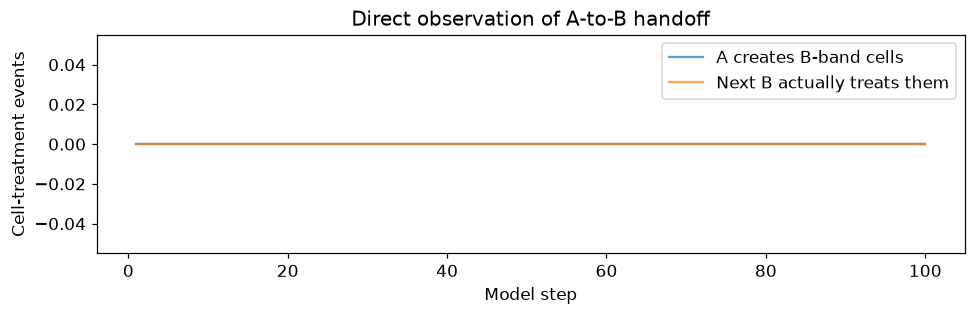

In [6]:
class HandoffRecorder:
    """Observe applied removal; delegate every action to the existing policy."""
    def __init__(self, schedule):
        self.schedule = schedule
        self.inner = make_scheduled_policy(schedule, params, budget)
        self.reset()

    def reset(self):
        self.inner.reset()
        self.index = 0
        self.previous_handoff = None
        self.rows = []

    def __call__(self, grid, mask):
        label = self.schedule[self.index]
        removal, cost = self.inner(grid, mask)
        treated = mask & (removal > 0)
        after = grid - removal
        entering = treated & (grid >= params.boundary) & (after >= params.b_lower) & (after < params.boundary)
        linked = np.zeros_like(mask)
        if label == "B" and self.previous_handoff is not None:
            linked = treated & self.previous_handoff
        self.rows.append({"step": self.index+1, "policy": label,
            "treated": int(treated.sum()),
            "A_to_B_band": int(entering.sum()) if label == "A" else 0,
            "next_B_treated": int(linked.sum()),
            "removed": float(removal[mask].sum()), "cost": cost})
        self.previous_handoff = entering.copy() if label == "A" else None
        self.index += 1
        return removal, cost

recorder = HandoffRecorder(schedules["AB"])
traced = run_experiment("AB traced", metro, config, recorder)
np.testing.assert_allclose(traced.history, runs["AB"].history, equal_nan=True)
np.testing.assert_allclose(traced.cost_history, runs["AB"].cost_history)
trace = pd.DataFrame(recorder.rows)
entered = int(trace.A_to_B_band.sum())
linked = int(trace.next_B_treated.sum())
b_total = int(trace.loc[trace.policy == "B", "treated"].sum())
display(Markdown(f"**実測：A後にBの密度範囲へ入った延べ {entered:,} セルのうち、"
    f"次のBで処理されたのは {linked:,} セル。** "
    f"これはBの全処理 {b_total:,} セルの {linked/b_total:.1%} です。"))
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(trace.step, trace.A_to_B_band, label="A creates B-band cells", alpha=.7)
ax.plot(trace.step, trace.next_B_treated, label="Next B actually treats them", alpha=.7)
ax.set(xlabel="Model step", ylabel="Cell-treatment events", title="Direct observation of A-to-B handoff")
ax.legend(); fig.tight_layout(); plt.show()

**実測では引き継ぎは0回でした。直接のA→B引き継ぎ説は、この代表条件では支持されません。**
Aは高密度の上位セルから選ぶため、15%削減してもBの上限まで下がらないのです。
逆転は再現されるので、直接の引き継ぎがなくても成立することが分かります。
異なる密度帯の処理を分担し、その順序が成長・伝播・処理対象・支出を変えるという説明が、現時点の作業仮説です。
空間的な伝播、非線形な成長、対象の順位、処理量と費用も同時に変わります。
寄与を分離するには、伝播を外した対照や支出・除去量をそろえた追加実験が必要です。
「実測した仕組み」と「まだ検証していない因果の強さ」を分けます。

### 5. 選びやすい成功例だけを見ていないか？

Step09は8パラメータの離散空間から2,400組を調べた探索です。全組合せを試したわけではありません。
候補2036はその後のブロック・少数ランダム検証を通して選ばれました。したがって以下の割合は現実世界での成功確率ではありません。

In [7]:
screen = pd.read_csv(ROOT / "results/strong_parrondo_equal_budget_search.csv")
parameter_names = ["a_rate", "b_rate", "max_cells", "boundary", "b_lower", "growth_rate", "diffusion_rate", "budget"]
display(pd.DataFrame({"parameter": parameter_names,
    "sampled levels": [", ".join(map(str, sorted(screen[n].unique()))) for n in parameter_names]}))
either = (screen.a_relative_change > 0) & (screen.b_relative_change > 0) & ((screen.ab_relative_change < 0) | (screen.ba_relative_change < 0))
both = (screen.a_relative_change > 0) & (screen.b_relative_change > 0) & (screen.ab_relative_change < 0) & (screen.ba_relative_change < 0)
print(f"Screened: {len(screen):,}; AB or BA reversal: {either.sum()}; both: {both.sum()}")
print("These counts do not include the later block/random requirements.")

Screened: 2,400; AB or BA reversal: 53; both: 51
These counts do not include the later block/random requirements.


,parameter,sampled levels
0,a_rate,"0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0...."
1,b_rate,"0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0...."
2,max_cells,"25, 50, 75, 100, 150, 200, 300"
3,boundary,"0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9"
4,b_lower,"0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0...."
5,growth_rate,"0.01, 0.015, 0.02, 0.025, 0.03, 0.035, 0.04"
6,diffusion_rate,"0.0025, 0.005, 0.01, 0.015, 0.02, 0.03"
7,budget,"150000, 200000, 250000, 300000, 350000, 400000..."


### 6. 最新のStep10：いつまで、どこまで成り立つ？

ここだけは **保存済みのStep10結果**です。2候補×（4期間＋9環境設定）×6戦略＝156行と、
2候補×200ランダム順序＝400行の完全性を確認します。ランダム化するのは順序だけで、初期分布や生態パラメータではありません。
期間を変える比較では予算上限を期間に比例させています。

Change (%)       A block B  A only     AB  B block A  B only     BA
sample_id steps                                                    
1370      52         1.617   4.188 -0.989      0.621  -0.575 -1.028
          100        4.913   7.459 -0.192      2.888   0.691 -0.242
          156        7.793   9.938  0.286      5.346   1.301  0.235
          260       14.347  11.780  0.395      8.649   1.451  0.336
2036      52         1.708   2.324 -0.169      0.809   0.946 -0.226
          100        4.705   4.196 -0.206      2.993   1.421 -0.349
          156        8.029   6.362  0.389      4.212   2.285  0.156
          260       13.405   8.610  1.306      5.518   2.736  0.966

,trials,wins,win_fraction,median
sample_id,,,,
1370,200,110,0.550,-0.000775
2036,200,105,0.525,-0.000194


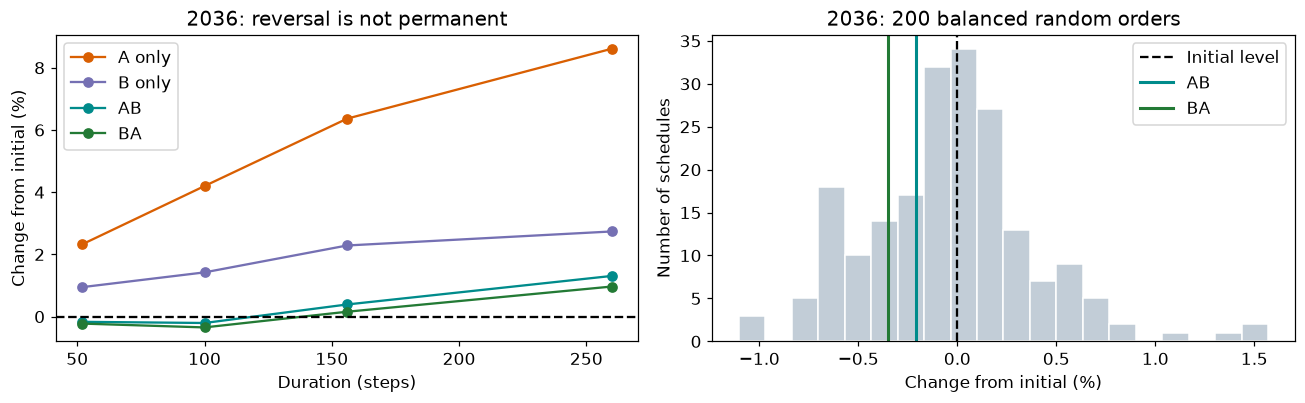

In [8]:
det = pd.read_csv(ROOT / "results/step10_deterministic_robustness.csv")
random = pd.read_csv(ROOT / "results/step10_random_schedule_robustness.csv")
assert len(det) == 156 and not det.duplicated(["sample_id", "scenario_type", "scenario", "strategy"]).any()
assert len(random) == 400 and not random.duplicated(["sample_id", "seed"]).any()
for sample in [2036, 1370]:
    assert set(random.loc[random.sample_id == sample, "seed"]) == set(range(200))
duration = det[det.scenario_type == "duration"].pivot(index=["sample_id", "steps"], columns="strategy", values="relative_change")
display((100*duration).round(3).rename_axis(columns="Change (%)"))
random_summary = random.groupby("sample_id").relative_change.agg(
    trials="count", wins=lambda s: int((s<0).sum()), win_fraction=lambda s: (s<0).mean(), median="median")
display(random_summary)
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for name in ["A only", "B only", "AB", "BA"]:
    axes[0].plot(duration.loc[2036].index, 100*duration.loc[2036, name], marker="o", label=name, color=colors[name])
axes[0].axhline(0, color="black", ls="--")
axes[0].set(title="2036: reversal is not permanent", xlabel="Duration (steps)", ylabel="Change from initial (%)")
axes[0].legend()
sample_random = random[random.sample_id == 2036]
axes[1].hist(100*sample_random.relative_change, bins=20, color="#c2cdd7", edgecolor="white")
axes[1].axvline(0, color="black", ls="--", label="Initial level")
for name in ["AB", "BA"]:
    axes[1].axvline(summary.loc[name, "change (%)"], color=colors[name], label=name, lw=2)
axes[1].set(title="2036: 200 balanced random orders", xlabel="Change from initial (%)", ylabel="Number of schedules")
axes[1].legend(); fig.tight_layout(); plt.show()

All-six condition holds in 5/9 local ecology scenarios.


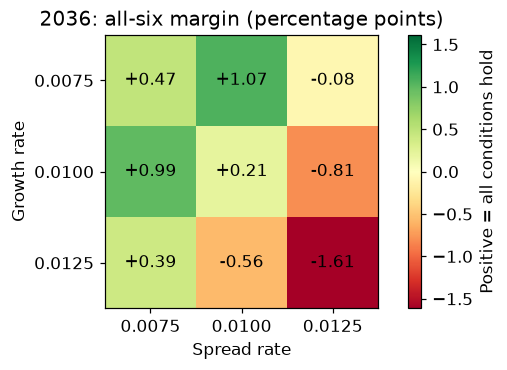

In [9]:
ecology = det[(det.sample_id == 2036) & (det.scenario_type == "ecology")]
wide = ecology.pivot(index=["growth_rate", "diffusion_rate"], columns="strategy", values="relative_change")
# Positive only when ALL six required inequalities hold, including both AB and BA.
margin = pd.concat([wide[["A only", "B only", "A block B", "B block A"]], -wide[["AB", "BA"]]], axis=1).min(axis=1)
table = 100*margin.unstack("diffusion_rate")
fig, ax = plt.subplots(figsize=(5.8, 3.5))
limit = np.abs(table.to_numpy()).max()
im = ax.imshow(table, cmap="RdYlGn", vmin=-limit, vmax=limit)
ax.set_xticks(range(len(table.columns)), [f"{v:.4f}" for v in table.columns])
ax.set_yticks(range(len(table.index)), [f"{v:.4f}" for v in table.index])
for i in range(table.shape[0]):
    for j in range(table.shape[1]):
        ax.text(j, i, f"{table.iloc[i,j]:+.2f}", ha="center", va="center")
ax.set(xlabel="Spread rate", ylabel="Growth rate", title="2036: all-six margin (percentage points)")
fig.colorbar(im, ax=ax, label="Positive = all conditions hold")
fig.tight_layout(); plt.show()
print(f"All-six condition holds in {(margin>0).sum()}/{len(margin)} local ecology scenarios.")

### 7. デモで伝える結論

**発見：** このモデルでは政策が状態を変え、次の政策が使える対象も変わります。
候補2036では100ステップ後に「単独で悪化、混合で改善」という逆転が再現されますが、
仮説として考えた直接のA→B引き継ぎは観測されませんでした。
同じA/B回数でもブロック順序は悪化するため、順番を無視できません。

**言い過ぎないこと：** 200通りのランダム順序では2036は105/200、1370は110/200が改善しました。
初期の20通りでは両候補とも45%でしたが、最新結果で「大半のランダム順序は失敗する」という説明は支持されません。
両候補とも156・260ステップではAB/BAが初期値を上回ります。よって**条件と期間に依存する、順序依存の政策混合効果**と解釈します。
共通予算上限は支出一致ではなく、モデルは現実の雑草データで校正されていません。

**次の研究：** 支出をそろえた比較、引き継ぎの介入実験、別の初期分布、探索に使っていない条件での検証を行えば、
機序と一般性をより強く主張できます。このNBの測定はそのための出発点です。

### 発表準備・レポートへの橋渡し（本編の後）

Rubric（18 September 2026）では、Python 3での再現、コード・式・図・解釈をつないだNB、モデルの検証、
両メンバーが説明できる10分以内のデモが求められています。担当はチームで決め、双方がA/Bの条件と限界を説明できるようにします。

|Rubricの観点|このNBの対応|提出までに確認すること|
|---|---|---|
|問い・背景|冒頭とモデル説明|先行研究の調査と正確な引用|
|仕様・根拠|初期化、成長・伝播、閾値、費用|人口密度仮定と未校正パラメータの説明|
|実験設計|単独・周期・ブロック・ランダム、期間・環境|候補選択による偏りを明記|
|結果と考察|実測表、図、引き継ぎと限界|長期成功・周期固有・支出一致と誤記しない|
|正しさ・再現|Run All内の状態・予算・対照・観測不変性チェック|既存の境界ケース検証も説明できること|
|独自性・貢献|空間モデルと状態依存政策順序の検討|各人の実際の貢献と既存手法を区別|
|GitHub活動|この成果物のコミット|共同作業・レビューの実績は別途必要|

レポートの指定は本文最大5枚（図・参考文献・付録を除く）、A4、11pt、余白1 inch、段落中心の科学的記述です。
このNBはデモ用であり、レポート本文の代用ではありません。

**質問に備える：** なぜB単独は高密度に効かない？／なぜ同じ予算上限でも支出が違う？／なぜ長期には逆転が消える？／
今回の引き継ぎ観測で何が証明できて、何が証明できない？

**追跡先：** [実験Step01–10](../experiments/)、[モデル](../src/weed_ca.py)、[政策](../src/weed_policies.py)、
[順序と予算](../src/experiment_schedules.py)、[保存結果](../results/)。
データはリポジトリ内のWA Localitiesと2021 Census CSVを使用します。取得元は[README](../README.md)を参照。
地図はポリゴンをラスタ化したモデル状態であり、観測された雑草分布図ではありません。